<a href="https://colab.research.google.com/github/somnath3112/DRL-fun-da/blob/somb/Saving_loading_dqn_%2B_Episode_generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stable Baselines3 - Training, Saving and Loading

Github Repo: [https://github.com/DLR-RM/stable-baselines3](https://github.com/DLR-RM/stable-baselines3)


[RL Baselines3 Zoo](https://github.com/DLR-RM/rl-baselines3-zoo) is a training framework for Reinforcement Learning (RL), using Stable Baselines3.

It provides scripts for training, evaluating agents, tuning hyperparameters, plotting results and recording videos.

Documentation is available online: [https://stable-baselines3.readthedocs.io/](https://stable-baselines3.readthedocs.io/)



## Install Dependencies and Stable Baselines Using Pip


```
pip install stable-baselines3[extra]
```

In [ ]:
# for autoformatting
# %load_ext jupyter_black

In [ ]:
!apt-get update && apt-get install swig cmake
!pip install box2d-py
!pip install gymnasium[box2d]
!pip install "stable-baselines3[extra]>=2.0.0a4"

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading

## Import policy, RL agent, ...

In [ ]:
import gymnasium as gym
import numpy as np

from stable_baselines3 import DQN

## Create the Gym env and instantiate the agent

For this example, we will use Lunar Lander environment.

"Landing outside landing pad is possible. Fuel is infinite, so an agent can learn to fly and then land on its first attempt. Four discrete actions available: do nothing, fire left orientation engine, fire main engine, fire right orientation engine. "

Lunar Lander environment: [https://gymnasium.farama.org/environments/box2d/lunar_lander/](https://gymnasium.farama.org/environments/box2d/lunar_lander/)

![Lunar Lander](https://cdn-images-1.medium.com/max/960/1*f4VZPKOI0PYNWiwt0la0Rg.gif)


We chose the MlpPolicy because input of Lunar Lander is a feature vector, not images.

The type of action to use (discrete/continuous) will be automatically deduced from the environment action space



In [ ]:
model = DQN(
    "MlpPolicy",
    "LunarLander-v3",
    verbose=1,
    exploration_final_eps=0.1,
    target_update_interval=250,
)

Using cuda device
Creating environment from the given name 'LunarLander-v3'
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.11/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.11/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.11/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google.cloud')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-pa

We load a helper function to evaluate the agent:

In [ ]:
from stable_baselines3.common.evaluation import evaluate_policy

Let's evaluate the un-trained agent, this should be a random agent.

In [ ]:
# Separate env for evaluation
eval_env = gym.make("LunarLander-v3")

# Random Agent, before training
mean_reward, std_reward = evaluate_policy(
    model,
    eval_env,
    n_eval_episodes=10,
    deterministic=True,
)

print(f"mean_reward={mean_reward:.2f} +/- {std_reward}")

/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/evaluation.py:67: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


mean_reward=-154.38 +/- 44.53565044286411


## Train the agent and save it

Warning: this may take a while

In [ ]:
# Train the agent
model.learn(total_timesteps=int(1e5))
# Save the agent
model.save("dqn_lunar")
del model  # delete trained model to demonstrate loading

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 95       |
|    ep_rew_mean      | -173     |
|    exploration_rate | 0.966    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 307      |
|    time_elapsed     | 1        |
|    total_timesteps  | 380      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 4.16     |
|    n_updates        | 69       |
----------------------------------


KeyboardInterrupt: 

## Load the trained agent

In [ ]:
model = DQN.load("dqn_lunar")

In [ ]:
# Evaluate the trained agent
mean_reward, std_reward = evaluate_policy(model, eval_env, n_eval_episodes=10, deterministic=True)

print(f"mean_reward={mean_reward:.2f} +/- {std_reward}")

# Fun with Lunar Lander

In [ ]:
import numpy as np
import imageio

In [ ]:
#@title The environment
new_env = gym.make("LunarLander-v3", render_mode='rgb_array')

In [ ]:
#@title Random episode

N = 30
current_rewards = 0.
current_lengths = 0.

# List to store frames
frames = []

obs, info = new_env.reset()

for i in range(N):
  actions = int(np.random.choice(4,1)[0])
  print(f"The action is: {actions}, the type is {type(actions)}")
  obs, reward, done, truncated, info = new_env.step(actions)


  current_rewards += reward
  current_lengths += 1
  # Capture the frame
  frames.append(new_env.render())

  if done:
      break  # Stop if episode ends

The action is: 1, the type is <class 'int'>
The action is: 1, the type is <class 'int'>
The action is: 1, the type is <class 'int'>
The action is: 2, the type is <class 'int'>
The action is: 3, the type is <class 'int'>
The action is: 2, the type is <class 'int'>
The action is: 0, the type is <class 'int'>
The action is: 2, the type is <class 'int'>
The action is: 3, the type is <class 'int'>
The action is: 2, the type is <class 'int'>
The action is: 3, the type is <class 'int'>
The action is: 0, the type is <class 'int'>
The action is: 0, the type is <class 'int'>
The action is: 3, the type is <class 'int'>
The action is: 2, the type is <class 'int'>
The action is: 2, the type is <class 'int'>
The action is: 1, the type is <class 'int'>
The action is: 0, the type is <class 'int'>
The action is: 0, the type is <class 'int'>
The action is: 3, the type is <class 'int'>
The action is: 0, the type is <class 'int'>
The action is: 1, the type is <class 'int'>
The action is: 0, the type is <c

In [ ]:
#@title Save as a video file
video_filename = "lunar_lander.mp4"
imageio.mimsave(video_filename, frames, fps=30)

print(f"Video saved as {video_filename}")
print('Download the video and run, see below')

Video saved as lunar_lander.mp4


#### Download the video and run (expand this)

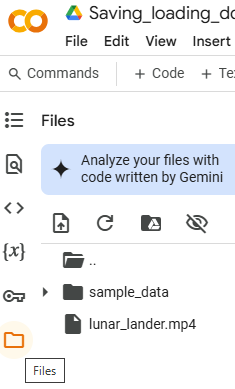

### More

In [ ]:
# Close environment
new_env.close()

# new_env.render("human")

# Ends